In [ ]:
!pip install polars xgboost lightgbm

## FASE 1

 ### 1- Subir el archivo

In [33]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

### 2 — Tercera celda: cargar con Polars

In [34]:
import polars as pl

df = pl.read_csv('NYC.csv')
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 1458644, Columnas: 11


id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,i64,str,str,i64,f64,f64,f64,f64,str,i64
"""id2875421""",2,"""2016-03-14 17:24:55""","""2016-03-14 17:32:30""",1,-73.982155,40.767937,-73.96463,40.765602,"""N""",455
"""id2377394""",1,"""2016-06-12 00:43:35""","""2016-06-12 00:54:38""",1,-73.980415,40.738564,-73.999481,40.731152,"""N""",663
"""id3858529""",2,"""2016-01-19 11:35:24""","""2016-01-19 12:10:48""",1,-73.979027,40.763939,-74.005333,40.710087,"""N""",2124
"""id3504673""",2,"""2016-04-06 19:32:31""","""2016-04-06 19:39:40""",1,-74.01004,40.719971,-74.012268,40.706718,"""N""",429
"""id2181028""",2,"""2016-03-26 13:30:55""","""2016-03-26 13:38:10""",1,-73.973053,40.793209,-73.972923,40.78252,"""N""",435


EXTRA -  Reducir el conjunto de datos

In [35]:
# Usar solo 100,000 filas
df = df.sample(n=100000, seed=42)
print(df.shape)

(100000, 11)


### 3 — Ver tipos de datos y estructura

In [36]:
print(df.dtypes)
print()
print(df.columns)

[String, Int64, String, String, Int64, Float64, Float64, Float64, Float64, String, Int64]

['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


### 4 — Estadísticas descriptivas

In [37]:
df.describe()

statistic,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
str,str,f64,str,str,f64,f64,f64,f64,f64,str,f64
"""count""","""100000""",100000.0,"""100000""","""100000""",100000.0,100000.0,100000.0,100000.0,100000.0,"""100000""",100000.0
"""null_count""","""0""",0.0,"""0""","""0""",0.0,0.0,0.0,0.0,0.0,"""0""",0.0
"""mean""",null,1.53255,null,null,1.65954,-73.973788,40.751083,-73.973843,40.751819,null,959.60096
"""std""",null,0.498942,null,null,1.307434,0.157471,0.030245,0.158252,0.035878,null,3247.001743
"""min""","""id0000020""",1.0,"""2016-01-01 00:01:20""","""2016-01-01 00:13:36""",0.0,-121.933342,37.389381,-121.933304,37.389511,"""N""",1.0
"""25%""",null,1.0,null,null,1.0,-73.991707,40.737457,-73.991241,40.73587,null,398.0
"""50%""",null,2.0,null,null,1.0,-73.981644,40.754353,-73.979706,40.754559,null,664.0
"""75%""",null,2.0,null,null,2.0,-73.967216,40.768555,-73.962883,40.77,null,1075.0
"""max""","""id3999929""",2.0,"""2016-06-30 23:58:30""","""2016-07-01 12:40:50""",7.0,-73.353729,41.586273,-73.193268,43.921028,"""Y""",86377.0


### 5 — Revisar valores faltantes

In [8]:
nulos = df.select([
    pl.col(c).is_null().sum().alias(c)
    for c in df.columns
])
print(nulos)

shape: (1, 11)
┌─────┬───────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ id  ┆ vendor_id ┆ pickup_dat ┆ dropoff_da ┆ … ┆ dropoff_lo ┆ dropoff_la ┆ store_and_ ┆ trip_dura │
│ --- ┆ ---       ┆ etime      ┆ tetime     ┆   ┆ ngitude    ┆ titude     ┆ fwd_flag   ┆ tion      │
│ u32 ┆ u32       ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│     ┆           ┆ u32        ┆ u32        ┆   ┆ u32        ┆ u32        ┆ u32        ┆ u32       │
╞═════╪═══════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ 0   ┆ 0         ┆ 0          ┆ 0          ┆ … ┆ 0          ┆ 0          ┆ 0          ┆ 0         │
└─────┴───────────┴────────────┴────────────┴───┴────────────┴────────────┴────────────┴───────────┘


#### Valores faltantes
El dataset no presenta valores nulos en ninguna columna. Esto se debe a que es un
dataset ya curado de Kaggle. Para cumplir con los requisitos de la tarea sobre
manejo de datos faltantes, se simularán valores nulos de forma controlada en la
fase de Feature Engineering.

### 6 — Analizar la variable objetivo (duración_viaje)

In [9]:
print("Estadísticas de trip_duration:")
print(df.select(pl.col("trip_duration")).describe())

print("\nValor mínimo:", df["trip_duration"].min())
print("Valor máximo:", df["trip_duration"].max())
print("Promedio:", df["trip_duration"].mean())

Estadísticas de trip_duration:
shape: (9, 2)
┌────────────┬───────────────┐
│ statistic  ┆ trip_duration │
│ ---        ┆ ---           │
│ str        ┆ f64           │
╞════════════╪═══════════════╡
│ count      ┆ 100000.0      │
│ null_count ┆ 0.0           │
│ mean       ┆ 959.60096     │
│ std        ┆ 3247.001743   │
│ min        ┆ 1.0           │
│ 25%        ┆ 398.0         │
│ 50%        ┆ 664.0         │
│ 75%        ┆ 1075.0        │
│ max        ┆ 86377.0       │
└────────────┴───────────────┘

Valor mínimo: 1
Valor máximo: 86377
Promedio: 959.60096


 ### 7 — Visualizar distribución de la variable objetivo

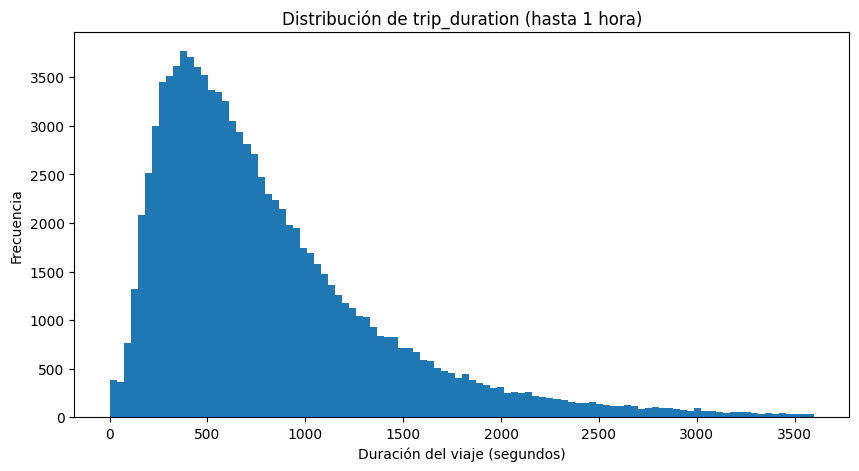

In [10]:
import matplotlib.pyplot as plt

# Convertimos a pandas solo para graficar (Polars no tiene graficación nativa)
duraciones = df["trip_duration"].to_list()

plt.figure(figsize=(10,5))
plt.hist(duraciones, bins=100, range=(0, 3600))  # limitamos a 1 hora para ver mejor
plt.xlabel("Duración del viaje (segundos)")
plt.ylabel("Frecuencia")
plt.title("Distribución de trip_duration (hasta 1 hora)")
plt.savefig("distribucion_trip_duration.png")
plt.show()

### 8 — Distribución de otras variables importantes

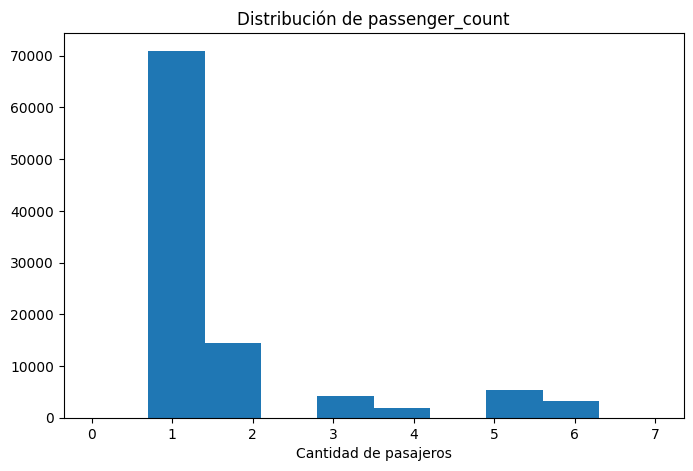

In [11]:
# Cantidad de pasajeros
plt.figure(figsize=(8,5))
plt.hist(df["passenger_count"].to_list(), bins=10)
plt.xlabel("Cantidad de pasajeros")
plt.title("Distribución de passenger_count")
plt.savefig("distribucion_passenger_count.png")
plt.show()

### 9 — Correlaciones

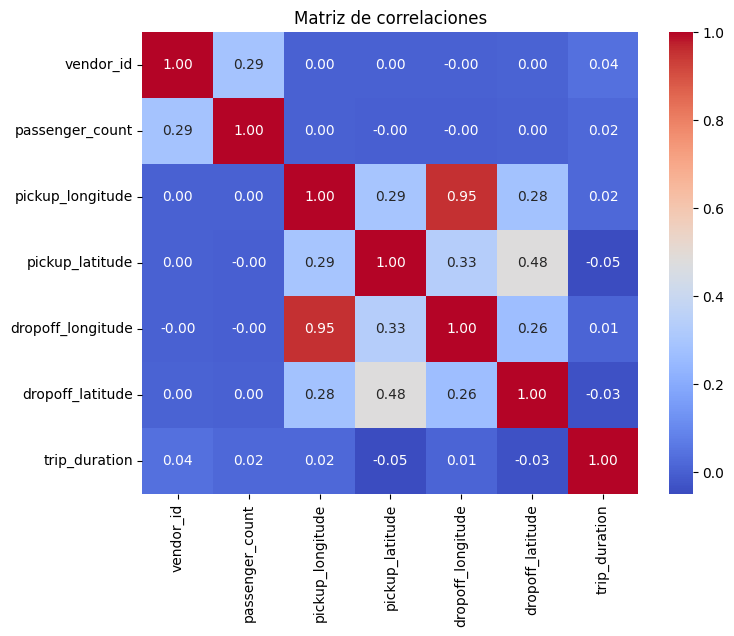

In [12]:
import seaborn as sns

# Seleccionamos solo columnas numéricas
df_numerico = df.select(["vendor_id", "passenger_count", "pickup_longitude",
                           "pickup_latitude", "dropoff_longitude", "dropoff_latitude",
                           "trip_duration"])

# Convertimos a pandas solo para el heatmap (seaborn lo necesita)
correlaciones = df_numerico.to_pandas().corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlaciones, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlaciones")
plt.savefig("correlaciones.png")
plt.show()

## Fase 2: Ingeniería de características

### 10 — Crear nuevas características desde las fechas

In [13]:
df = df.with_columns([
    pl.col("pickup_datetime").str.to_datetime("%Y-%m-%d %H:%M:%S"),
    pl.col("dropoff_datetime").str.to_datetime("%Y-%m-%d %H:%M:%S")
])

df = df.with_columns([
    pl.col("pickup_datetime").dt.hour().alias("pickup_hour"),
    pl.col("pickup_datetime").dt.weekday().alias("pickup_weekday"),
    pl.col("pickup_datetime").dt.month().alias("pickup_month"),
    pl.col("pickup_datetime").dt.day().alias("pickup_day"),
])

print(df.head())

shape: (5, 15)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ vendor_id ┆ pickup_da ┆ dropoff_d ┆ … ┆ pickup_ho ┆ pickup_we ┆ pickup_mo ┆ pickup_d │
│ ---       ┆ ---       ┆ tetime    ┆ atetime   ┆   ┆ ur        ┆ ekday     ┆ nth       ┆ ay       │
│ str       ┆ i64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ datetime[ ┆ datetime[ ┆   ┆ i8        ┆ i8        ┆ i8        ┆ i8       │
│           ┆           ┆ μs]       ┆ μs]       ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ id2922225 ┆ 2         ┆ 2016-05-1 ┆ 2016-05-1 ┆ … ┆ 15        ┆ 4         ┆ 5         ┆ 12       │
│           ┆           ┆ 2         ┆ 2         ┆   ┆           ┆           ┆           ┆          │
│           ┆           ┆ 15:13:52  ┆ 17:01:57  ┆   ┆           ┆           

 ### 11 — Calcular distancia entre recogida y devolución

In [14]:
import numpy as np

df = df.with_columns([
    ((pl.col("dropoff_latitude") - pl.col("pickup_latitude"))**2 +
     (pl.col("dropoff_longitude") - pl.col("pickup_longitude"))**2
    ).sqrt().alias("distancia_directa")
])

print(df.select(["distancia_directa"]).describe())

shape: (9, 2)
┌────────────┬───────────────────┐
│ statistic  ┆ distancia_directa │
│ ---        ┆ ---               │
│ str        ┆ f64               │
╞════════════╪═══════════════════╡
│ count      ┆ 100000.0          │
│ null_count ┆ 0.0               │
│ mean       ┆ 0.035622          │
│ std        ┆ 0.047121          │
│ min        ┆ 0.0               │
│ 25%        ┆ 0.012578          │
│ 50%        ┆ 0.021322          │
│ 75%        ┆ 0.038658          │
│ max        ┆ 6.3723            │
└────────────┴───────────────────┘


### 12— Filtrado de registros (limpieza)
Eliminamos viajes que claramente son errores de datos:

In [15]:
filas_antes = df.shape[0]

df = df.filter(
    (pl.col("trip_duration") >= 60) &      # mínimo 1 minuto
    (pl.col("trip_duration") <= 7200) &    # máximo 2 horas
    (pl.col("passenger_count") >= 1) &     # mínimo 1 pasajero
    (pl.col("passenger_count") <= 6) &     # máximo 6 pasajeros
    (pl.col("distancia_directa") > 0)      # distancia mayor a 0
)

filas_despues = df.shape[0]
print(f"Filas antes: {filas_antes}")
print(f"Filas después: {filas_despues}")
print(f"Filas eliminadas: {filas_antes - filas_despues}")

Filas antes: 100000
Filas después: 98984
Filas eliminadas: 1016


 ### 13 — Simular valores nulos y manejarlos

In [16]:
import random
random.seed(42)

# Simulamos nulos en passenger_count (5% de los datos)
indices_nulos = random.sample(range(df.shape[0]), int(df.shape[0] * 0.05))

df = df.with_columns([
    pl.when(pl.int_range(pl.len()).is_in(indices_nulos))
      .then(None)
      .otherwise(pl.col("passenger_count"))
      .alias("passenger_count")
])

print("Nulos en passenger_count:", df["passenger_count"].is_null().sum())

# Rellenamos los nulos con la mediana
df = df.with_columns([
    pl.col("passenger_count").fill_null(
        pl.col("passenger_count").median()
    )
])

print("Nulos después de fill_null:", df["passenger_count"].is_null().sum())

Nulos en passenger_count: 4949
Nulos después de fill_null: 0


### 14 — Group By - Calculamos estadísticas por hora del día:

In [17]:
resumen_por_hora = df.group_by("pickup_hour").agg([
    pl.col("trip_duration").mean().alias("duracion_promedio_hora"),
    pl.col("trip_duration").count().alias("cantidad_viajes_hora"),
    pl.col("distancia_directa").mean().alias("distancia_promedio_hora")
]).sort("pickup_hour")

print(resumen_por_hora)

shape: (24, 4)
┌─────────────┬────────────────────────┬──────────────────────┬─────────────────────────┐
│ pickup_hour ┆ duracion_promedio_hora ┆ cantidad_viajes_hora ┆ distancia_promedio_hora │
│ ---         ┆ ---                    ┆ ---                  ┆ ---                     │
│ i8          ┆ f64                    ┆ u32                  ┆ f64                     │
╞═════════════╪════════════════════════╪══════════════════════╪═════════════════════════╡
│ 0           ┆ 787.979137             ┆ 3547                 ┆ 0.042009                │
│ 1           ┆ 745.136732             ┆ 2589                 ┆ 0.040218                │
│ 2           ┆ 701.732077             ┆ 1911                 ┆ 0.039494                │
│ 3           ┆ 691.721429             ┆ 1400                 ┆ 0.042047                │
│ 4           ┆ 734.647573             ┆ 1030                 ┆ 0.05139                 │
│ …           ┆ …                      ┆ …                    ┆ …                    

### 15 — Unirse - Unimos el resumen por hora al dataset principal:

In [18]:
df = df.join(
    resumen_por_hora,
    on="pickup_hour",
    how="left"
)

print(f"Columnas después del join: {df.columns}")
print(df.head())

Columnas después del join: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_hour', 'pickup_weekday', 'pickup_month', 'pickup_day', 'distancia_directa', 'duracion_promedio_hora', 'cantidad_viajes_hora', 'distancia_promedio_hora']
shape: (5, 19)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ id        ┆ vendor_id ┆ pickup_da ┆ dropoff_d ┆ … ┆ distancia ┆ duracion_ ┆ cantidad_ ┆ distanci │
│ ---       ┆ ---       ┆ tetime    ┆ atetime   ┆   ┆ _directa  ┆ promedio_ ┆ viajes_ho ┆ a_promed │
│ str       ┆ i64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ hora      ┆ ra        ┆ io_hora  │
│           ┆           ┆ datetime[ ┆ datetime[ ┆   ┆ f64       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ μs]       ┆ μs]       ┆   ┆           ┆ f64       ┆ u32       ┆ f64  

### 16 — Convertir variable categórica a número

In [38]:
df = df.with_columns([
    pl.col("store_and_fwd_flag")
      .replace({"N": 0, "Y": 1})
      .cast(pl.Int32)
      .alias("store_and_fwd_flag")
])

print(df["store_and_fwd_flag"].value_counts())

shape: (2, 2)
┌────────────────────┬───────┐
│ store_and_fwd_flag ┆ count │
│ ---                ┆ ---   │
│ i32                ┆ u32   │
╞════════════════════╪═══════╡
│ 1                  ┆ 566   │
│ 0                  ┆ 99434 │
└────────────────────┴───────┘


### 17 — Guardar conjunto de datos procesado

In [20]:
df.write_csv("NYC_procesado.csv")
print("Dataset procesado guardado correctamente")
print(f"Shape final: {df.shape}")
print(f"Columnas finales: {df.columns}")

Dataset procesado guardado correctamente
Shape final: (98984, 19)
Columnas finales: ['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration', 'pickup_hour', 'pickup_weekday', 'pickup_month', 'pickup_day', 'distancia_directa', 'duracion_promedio_hora', 'cantidad_viajes_hora', 'distancia_promedio_hora']


## Fase 3: Machine Learning

### 18 — Preparar los datos para los modelos

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Columnas que vamos a usar como features
features = [
    "vendor_id",
    "passenger_count",
    "pickup_hour",
    "pickup_weekday",
    "pickup_month",
    "pickup_day",
    "distancia_directa",
    "store_and_fwd_flag",
    "duracion_promedio_hora",
    "distancia_promedio_hora"
]

# Variable objetivo
target = "trip_duration"

# Convertir a pandas para sklearn
df_pd = df.select(features + [target]).to_pandas()

# Separar X e y
X = df_pd[features]
y = df_pd[target]

# Dividir en entrenamiento y prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")

Entrenamiento: (79187, 10)
Prueba: (19797, 10)


### 19 — Modelo 1: Regresión Lineal

In [22]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

resultados = {}

# Entrenar
t = time.time()
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - t

# Predecir
pred_lr = modelo_lr.predict(X_test)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, pred_lr))
mae = mean_absolute_error(y_test, pred_lr)

resultados["Regresion Lineal"] = {
    "RMSE": round(rmse, 2),
    "MAE": round(mae, 2),
    "Tiempo (s)": round(tiempo_entrenamiento, 4)
}

print("✅ Regresión Lineal entrenada")
print(f"RMSE: {rmse:.2f} segundos")
print(f"MAE: {mae:.2f} segundos")
print(f"Tiempo: {tiempo_entrenamiento:.4f}s")

✅ Regresión Lineal entrenada
RMSE: 415.93 segundos
MAE: 295.16 segundos
Tiempo: 0.0478s


### 20 — Modelo 2: Bosque Aleatorio

In [24]:
from sklearn.ensemble import RandomForestRegressor

t = time.time()
modelo_rf = RandomForestRegressor(
    n_estimators=10,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - t

pred_rf = modelo_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
mae = mean_absolute_error(y_test, pred_rf)

resultados["Random Forest"] = {
    "RMSE": round(rmse, 2),
    "MAE": round(mae, 2),
    "Tiempo (s)": round(tiempo_entrenamiento, 4)
}

print("✅ Random Forest entrenado")
print(f"RMSE: {rmse:.2f} segundos")
print(f"MAE: {mae:.2f} segundos")
print(f"Tiempo: {tiempo_entrenamiento:.4f}s")

✅ Random Forest entrenado
RMSE: 359.96 segundos
MAE: 241.47 segundos
Tiempo: 2.1912s


### 21 — Modelo 3: XGBoost

In [25]:
import xgboost as xgb

t = time.time()
modelo_xgb = xgb.XGBRegressor(
    n_estimators=50,    # reducido de 100 a 50
    max_depth=4,        # limita profundidad
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"  # método más rápido para datasets grandes
)
modelo_xgb.fit(X_train, y_train)
tiempo_entrenamiento = time.time() - t

pred_xgb = modelo_xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae = mean_absolute_error(y_test, pred_xgb)

resultados["XGBoost"] = {
    "RMSE": round(rmse, 2),
    "MAE": round(mae, 2),
    "Tiempo (s)": round(tiempo_entrenamiento, 4)
}

print("✅ XGBoost entrenado")
print(f"RMSE: {rmse:.2f} segundos")
print(f"MAE: {mae:.2f} segundos")
print(f"Tiempo: {tiempo_entrenamiento:.4f}s")

✅ XGBoost entrenado
RMSE: 345.15 segundos
MAE: 231.19 segundos
Tiempo: 2.1183s


### 22 — Tabla comparativa de los 3 modelos

In [26]:
import pandas as pd

tabla = pd.DataFrame(resultados).T
print("\n Comparación de modelos:")
print(tabla.to_string())


📊 Comparación de modelos:
                    RMSE     MAE  Tiempo (s)
Regresion Lineal  415.93  295.16      0.0478
Random Forest     359.96  241.47      2.1912
XGBoost           345.15  231.19      2.1183


### 23 — Gráfica comparativa de RMSE

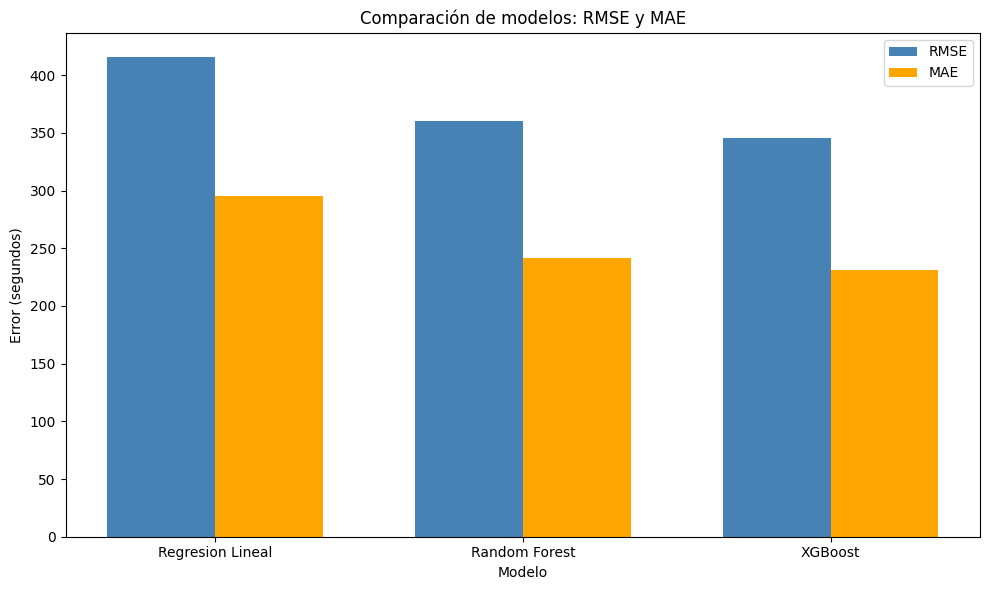

In [27]:
modelos = list(resultados.keys())
rmse_vals = [resultados[m]["RMSE"] for m in modelos]
mae_vals = [resultados[m]["MAE"] for m in modelos]

x = range(len(modelos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar([i - width/2 for i in x], rmse_vals, width, label='RMSE', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], mae_vals, width, label='MAE', color='orange')

ax.set_xlabel('Modelo')
ax.set_ylabel('Error (segundos)')
ax.set_title('Comparación de modelos: RMSE y MAE')
ax.set_xticks(list(x))
ax.set_xticklabels(modelos)
ax.legend()
plt.tight_layout()
plt.savefig("comparacion_modelos.png")
plt.show()

### 24 — Gráfica de importancia de características (XGBoost)

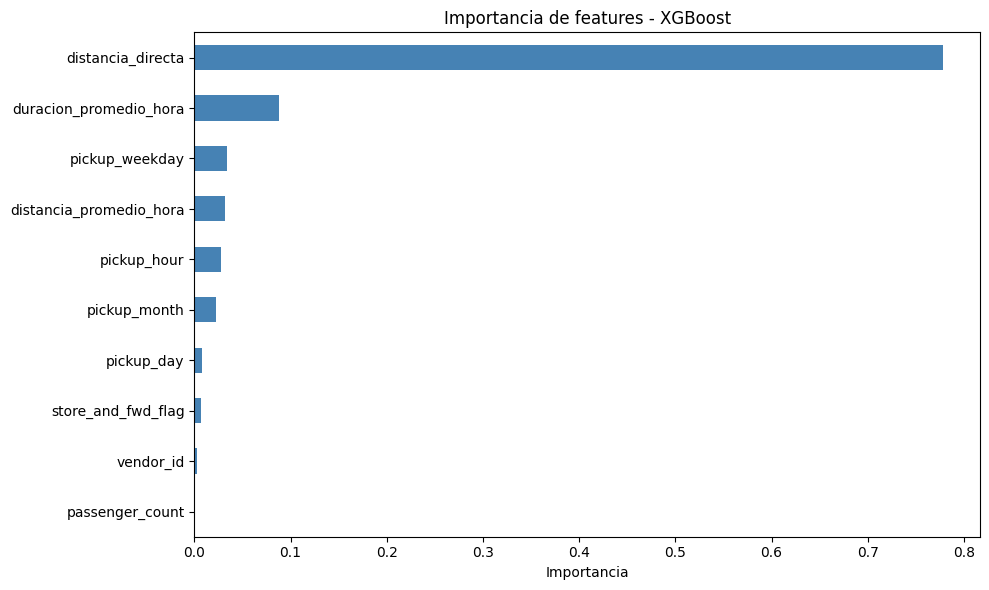

In [28]:
importancias = pd.Series(
    modelo_xgb.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='steelblue')
plt.title("Importancia de features - XGBoost")
plt.xlabel("Importancia")
plt.tight_layout()
plt.savefig("importancia_features.png")
plt.show()

## Fase 4 - Benchmark Polars vs Pandas

 ### 25 — Medir tiempos en Polars

In [29]:
import time

tiempos_polars = {}

# Usamos el dataset que ya está en memoria, no leemos el CSV completo
df_bench = df.head(100000)  # ya está cargado, no necesita leer el archivo

# "Simulamos" la lectura con lo que ya tenemos
t = time.time()
_ = df_bench.clone()
tiempos_polars["lectura"] = round(time.time() - t, 4)

# Filtrado
t = time.time()
df_bench.filter(
    (pl.col("trip_duration") >= 60) &
    (pl.col("trip_duration") <= 7200)
)
tiempos_polars["filtrado"] = round(time.time() - t, 4)

# Agregación group_by
t = time.time()
df_bench.group_by("vendor_id").agg([
    pl.col("trip_duration").mean().alias("duracion_promedio"),
    pl.col("trip_duration").count().alias("cantidad")
])
tiempos_polars["agregacion"] = round(time.time() - t, 4)

# Join
resumen_pl = df_bench.group_by("vendor_id").agg(
    pl.col("trip_duration").mean().alias("duracion_promedio")
)
t = time.time()
df_bench.join(resumen_pl, on="vendor_id", how="left")
tiempos_polars["join"] = round(time.time() - t, 4)

# Feature engineering
t = time.time()
df_bench.with_columns([
    pl.col("pickup_hour"),
    pl.col("distancia_directa")
])
tiempos_polars["feature_engineering"] = round(time.time() - t, 4)

print("✅ Tiempos Polars:")
for op, t in tiempos_polars.items():
    print(f"  {op}: {t}s")

✅ Tiempos Polars:
  lectura: 0.0003s
  filtrado: 0.0044s
  agregacion: 0.0038s
  join: 0.0055s
  feature_engineering: 0.0006s


### 26 — Medir los MISMOS tiempos en Pandas

In [39]:
import pandas as pd

tiempos_pandas = {}

# Lectura
t = time.time()
df_pd_bench = pd.read_csv("NYC.csv")
tiempos_pandas["lectura"] = round(time.time() - t, 4)

# Filtrado
t = time.time()
df_pd_bench[
    (df_pd_bench["trip_duration"] >= 60) &
    (df_pd_bench["trip_duration"] <= 7200)
]
tiempos_pandas["filtrado"] = round(time.time() - t, 4)

# Agregación group_by
t = time.time()
df_pd_bench.groupby("vendor_id").agg(
    duracion_promedio=("trip_duration", "mean"),
    cantidad=("trip_duration", "count")
)
tiempos_pandas["agregacion"] = round(time.time() - t, 4)

# Join
resumen_pd = df_pd_bench.groupby("vendor_id")["trip_duration"].mean().reset_index()
resumen_pd.columns = ["vendor_id", "duracion_promedio"]
t = time.time()
df_pd_bench.merge(resumen_pd, on="vendor_id", how="left")
tiempos_pandas["join"] = round(time.time() - t, 4)

# Feature engineering
t = time.time()
df_pd_bench["hora"] = pd.to_datetime(df_pd_bench["pickup_datetime"]).dt.hour
df_pd_bench["distancia"] = (
    (df_pd_bench["dropoff_latitude"] - df_pd_bench["pickup_latitude"])**2 +
    (df_pd_bench["dropoff_longitude"] - df_pd_bench["pickup_longitude"])**2
).pow(0.5)
tiempos_pandas["feature_engineering"] = round(time.time() - t, 4)

print("✅ Tiempos Pandas:")
for op, t in tiempos_pandas.items():
    print(f"  {op}: {t}s")

✅ Tiempos Pandas:
  lectura: 5.2703s
  filtrado: 0.1383s
  agregacion: 0.0376s
  join: 0.1977s
  feature_engineering: 0.8576s


### 27 — Tabla comparativa con speedup

In [31]:
operaciones = list(tiempos_polars.keys())

tabla_benchmark = pd.DataFrame({
    "Operación": operaciones,
    "Pandas (s)": [tiempos_pandas[op] for op in operaciones],
    "Polars (s)": [tiempos_polars[op] for op in operaciones],
    "Speedup (x)": [round(tiempos_pandas[op] / tiempos_polars[op], 2) for op in operaciones]
})

print("\n Benchmark Polars vs Pandas:")
print(tabla_benchmark.to_string(index=False))


📊 Benchmark Polars vs Pandas:
          Operación  Pandas (s)  Polars (s)  Speedup (x)
            lectura      7.1747      0.0003     23915.67
           filtrado      0.1617      0.0044        36.75
         agregacion      0.0470      0.0038        12.37
               join      0.2070      0.0055        37.64
feature_engineering      0.6022      0.0006      1003.67


### EXTRA - Esto es por si se pierden variable en el proceso

In [45]:
import polars as pl
import pandas as pd
import time

df_pl = pl.read_csv("NYC.csv")
df_pd_bench = pd.read_csv("NYC.csv")

print("✅ Dataframes listos")
print(f"Polars: {df_pl.shape}")
print(f"Pandas: {df_pd_bench.shape}")

✅ Dataframes listos
Polars: (1458644, 11)
Pandas: (1458644, 11)


### 28 — Experimento de escalabilidad 25/50/75/100%

In [46]:
porcentajes = [0.25, 0.50, 0.75, 1.00]
resultados_escala = []

for pct in porcentajes:
    n = int(len(df_pl) * pct)
    sub_pl = df_pl.head(n)
    sub_pd = df_pd_bench.head(n)

    # Tiempo Polars
    t = time.time()
    sub_pl.filter(
        (pl.col("trip_duration") >= 60) &
        (pl.col("trip_duration") <= 7200)
    ).group_by("vendor_id").agg(
        pl.col("trip_duration").mean()
    )
    t_polars = round(time.time() - t, 4)

    # Tiempo Pandas
    t = time.time()
    sub_pd[
        (sub_pd["trip_duration"] >= 60) &
        (sub_pd["trip_duration"] <= 7200)
    ].groupby("vendor_id")["trip_duration"].mean()
    t_pandas = round(time.time() - t, 4)

    resultados_escala.append({
        "Porcentaje": f"{int(pct*100)}%",
        "Filas": n,
        "Pandas (s)": t_pandas,
        "Polars (s)": t_polars,
        "Speedup (x)": round(t_pandas / t_polars, 2)
    })

tabla_escala = pd.DataFrame(resultados_escala)
print("\n Escalabilidad:")
print(tabla_escala.to_string(index=False))


📊 Escalabilidad:
Porcentaje   Filas  Pandas (s)  Polars (s)  Speedup (x)
       25%  364661      0.0429      0.0189         2.27
       50%  729322      0.0825      0.0305         2.70
       75% 1093983      0.1239      0.0423         2.93
      100% 1458644      0.1979      0.0574         3.45


### 29 — Experimento Lazy vs Eager

In [51]:
# Eager (inmediato)
t = time.time()
df_eager = pl.read_csv("NYC.csv")\
             .filter(pl.col("trip_duration") <= 7200)\
             .group_by("vendor_id")\
             .agg(pl.col("trip_duration").mean())
t_eager = round(time.time() - t, 4)

# Lazy (diferido)
t = time.time()
df_lazy = pl.scan_csv("NYC.csv")\
            .filter(pl.col("trip_duration") <= 7200)\
            .group_by("vendor_id")\
            .agg(pl.col("trip_duration").mean())\
            .collect()
t_lazy = round(time.time() - t, 4)

print(f" Eager: {t_eager}s")
print(f" Lazy:  {t_lazy}s")
print(f"Diferencia: {round(t_eager - t_lazy, 4)}s")

 Eager: 0.8667s
 Lazy:  0.2485s
Diferencia: 0.6182s


### 30 — Gráficas del benchmark

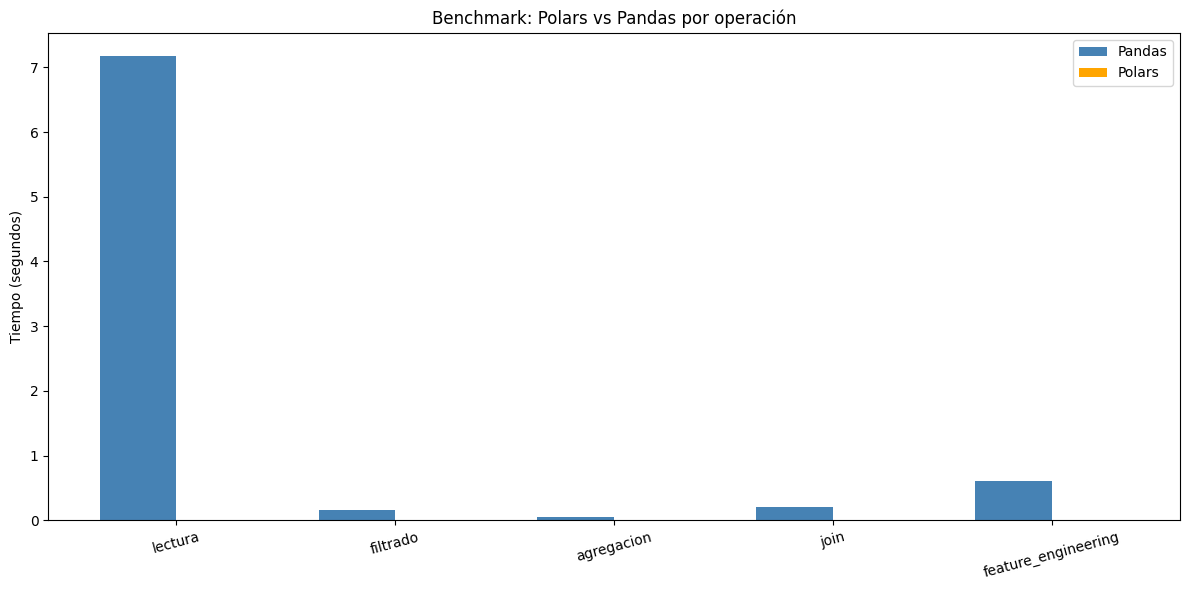

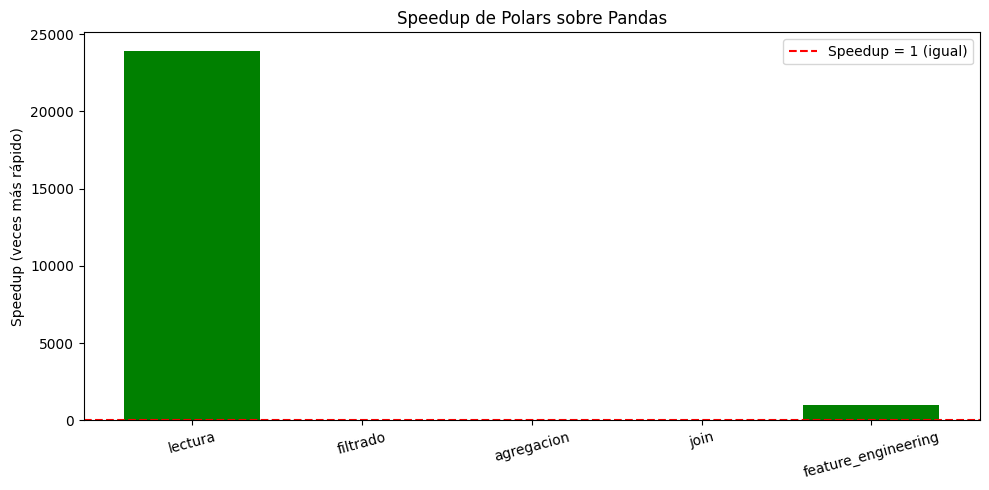

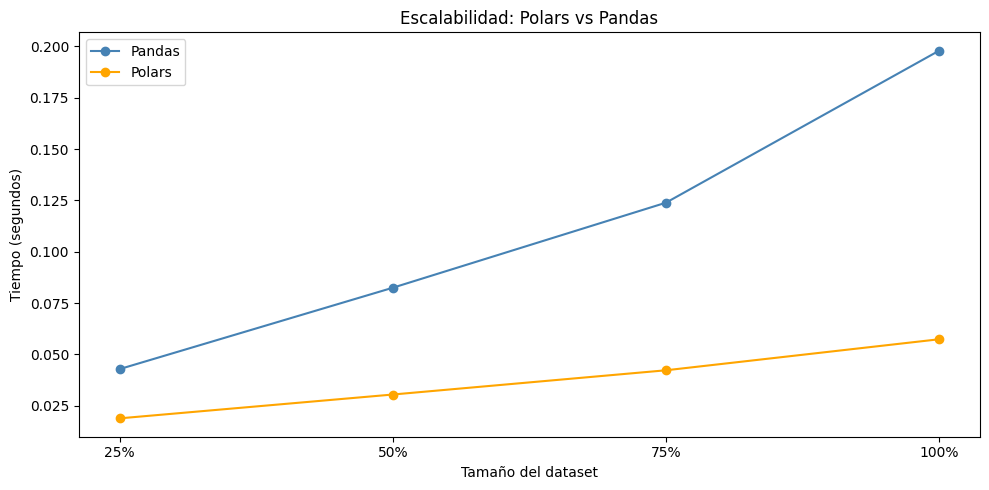

In [47]:
# Gráfica 1: Comparación por operación
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(operaciones))
width = 0.35

ax.bar([i - width/2 for i in x], tabla_benchmark["Pandas (s)"], width, label="Pandas", color="steelblue")
ax.bar([i + width/2 for i in x], tabla_benchmark["Polars (s)"], width, label="Polars", color="orange")
ax.set_xticks(list(x))
ax.set_xticklabels(operaciones, rotation=15)
ax.set_ylabel("Tiempo (segundos)")
ax.set_title("Benchmark: Polars vs Pandas por operación")
ax.legend()
plt.tight_layout()
plt.savefig("benchmark_operaciones.png")
plt.show()

# Gráfica 2: Speedup por operación
plt.figure(figsize=(10, 5))
plt.bar(operaciones, tabla_benchmark["Speedup (x)"], color="green")
plt.axhline(y=1, color="red", linestyle="--", label="Speedup = 1 (igual)")
plt.ylabel("Speedup (veces más rápido)")
plt.title("Speedup de Polars sobre Pandas")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_speedup.png")
plt.show()

# Gráfica 3: Escalabilidad
plt.figure(figsize=(10, 5))
plt.plot(tabla_escala["Porcentaje"], tabla_escala["Pandas (s)"], marker="o", label="Pandas", color="steelblue")
plt.plot(tabla_escala["Porcentaje"], tabla_escala["Polars (s)"], marker="o", label="Polars", color="orange")
plt.xlabel("Tamaño del dataset")
plt.ylabel("Tiempo (segundos)")
plt.title("Escalabilidad: Polars vs Pandas")
plt.legend()
plt.tight_layout()
plt.savefig("benchmark_escalabilidad.png")
plt.show()

### 31 — Experimento Lazy vs Eager

In [49]:
# Eager
t = time.time()
df_eager = pl.read_csv("NYC.csv")\
             .filter(pl.col("trip_duration") <= 7200)\
             .group_by("vendor_id")\
             .agg(pl.col("trip_duration").mean())
t_eager = round(time.time() - t, 4)

# Lazy
t = time.time()
df_lazy = pl.scan_csv("NYC.csv")\
            .filter(pl.col("trip_duration") <= 7200)\
            .group_by("vendor_id")\
            .agg(pl.col("trip_duration").mean())\
            .collect()
t_lazy = round(time.time() - t, 4)

print(f" Eager: {t_eager}s")
print(f" Lazy:  {t_lazy}s")
print(f"Diferencia: {round(t_eager - t_lazy, 4)}s")

 Eager: 0.8288s
 Lazy:  0.2416s
Diferencia: 0.5872s


### 32 — Descargar todas las gráficas

In [50]:
from google.colab import files

graficas = [
    "distribucion_trip_duration.png",
    "distribucion_passenger_count.png",
    "correlaciones.png",
    "comparacion_modelos.png",
    "importancia_features.png",
    "benchmark_operaciones.png",
    "benchmark_speedup.png",
    "benchmark_escalabilidad.png"
]

for g in graficas:
    if os.path.exists(g):
        files.download(g)
        print(f"✅ Descargada: {g}")
    else:
        print(f" No encontrada: {g}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargada: distribucion_trip_duration.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Descargada: benchmark_speedup.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargada: benchmark_escalabilidad.png
